## Exploring the CRCNS PVC-1 dataset

**Imports**

In [1]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import imageio
import io
from IPython.display import display, HTML
import base64
import seaborn as sns
from scipy.signal import correlate

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Metal (MPS) backend:", device)
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU:", device)
else:
    device = torch.device("cpu")
    print("Using CPU:", device)

from CRCNS_PVC1_Dataset import CRCNS_PVC1_Dataset

Using Apple Metal (MPS) backend: mps


In [3]:
data_path = "CRCNS_PVC1"  

**Dataset loading**

In [ ]:
# Dataset split: 'train' or 'test'
set = 'train'  

# Spatial resolution of output videos (width, height)
spatial_resol = (112, 112)  

# Use grayscale instead of RGB
grayscale = True  

# Whether to normalize video pixel intensities
normalize_videos = False  

# Whether to normalize neural responses 
normalize_responses = False

# Apply temporal smoothing to responses
response_smoothing = False  

# Add random noise to video stimuli
add_noise = False  

# Temporal resolution in milliseconds
temporal_resolution = 10

# Whether to split long recordings into shorter clips
split_into_clips = False

# Desired length of each clip (in frames) if splitting is enabled
new_clip_len = 3000 

In [16]:
dataset = CRCNS_PVC1_Dataset(
    path=data_path,
    set=set,
    spatial_resol=spatial_resol,
    grayscale=grayscale,
    normalize_videos=normalize_videos,
    normalize_responses=normalize_responses,
    response_smoothing=response_smoothing,
    add_noise=add_noise,
    temporal_resolution=temporal_resolution,
    split_into_clips=split_into_clips,
    new_clip_len=new_clip_len
)

print("Dataset loaded successfully.")
print("Video tensor shape:", dataset.videos.shape)       # Expected: (S, C, H, W, T)
print("Response tensor shape:", dataset.responses.shape) # Expected: (N, S, R, T)

train set contains 162 videos.
Dataset loaded successfully.
Video tensor shape: torch.Size([162, 1, 112, 112, 300])
Response tensor shape: torch.Size([23, 162, 10, 300])


Selecting the neurons to handle :

In [17]:
neurons_to_handle = range(dataset.N_neurons)
print(f'We have {len(neurons_to_handle)} neurons to handle.')

dataset.select_population(neurons_to_handle)

We have 23 neurons to handle.


**Dataset statistics**

In [18]:
video_clips = dataset.videos     # shape: (N_clips, 1, H, W, T)
response_clips = dataset.responses # shape: (N_neurons, N_clips, R, T)

N_clips, _, H, W, T = video_clips.shape
dt = dataset.dt  # ms

**Basics :**

In [19]:
print(f"Number of neurons: {dataset.N_neurons}")
print(f"Number of video clips: {len(dataset)}")
print(f"Video shape: {dataset.videos.shape}")     # (N_neurons, 1, H, W, T)
print(f"Response shape: {dataset.responses.shape}")  # (N_neurons, N_clips, R, T)


Number of neurons: 23
Number of video clips: 162
Video shape: torch.Size([162, 1, 112, 112, 300])
Response shape: torch.Size([23, 162, 10, 300])


**Clip length distribution (should be constant) :**

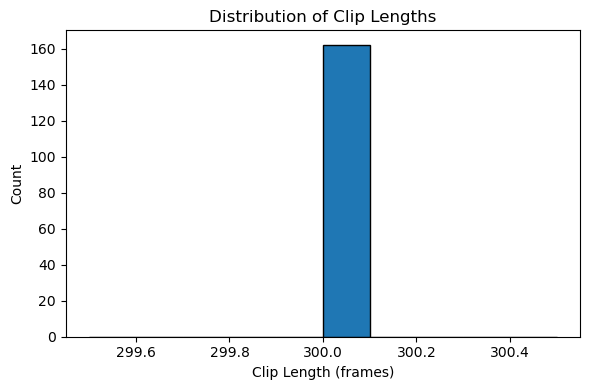

In [21]:
clip_lengths = [clip.shape[-1] for clip in video_clips]  

plt.figure(figsize=(6, 4))
plt.hist(clip_lengths, bins=10, edgecolor='black')
plt.xlabel("Clip Length (frames)")
plt.ylabel("Count")
plt.title("Distribution of Clip Lengths")
plt.tight_layout()
plt.show()

**Average response amplitude per clip :**

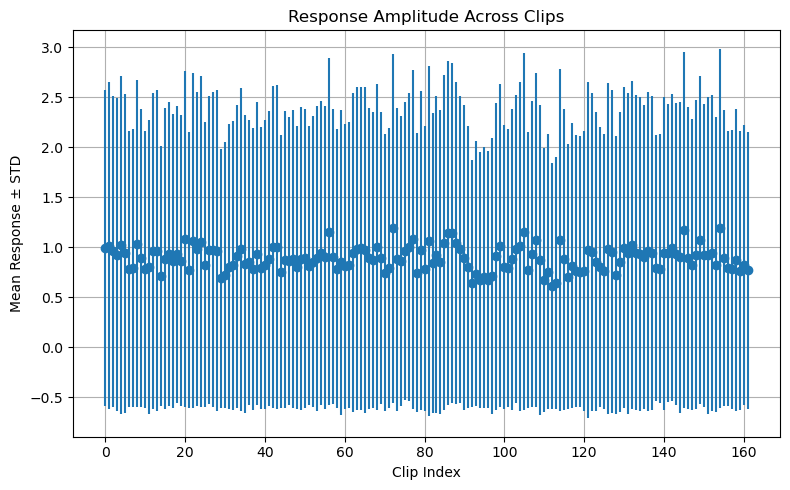

In [22]:
mean_responses = response_clips.mean(dim=(0, 2, -1)).numpy()  # shape: (N_clips,)
std_responses = response_clips.std(dim=(0, 2, -1)).numpy()

plt.figure(figsize=(8, 5))
plt.errorbar(np.arange(N_clips), mean_responses, yerr=std_responses, fmt='o')
plt.xlabel("Clip Index")
plt.ylabel("Mean Response ± STD")
plt.title("Response Amplitude Across Clips")
plt.grid(True)
plt.tight_layout()
plt.show()


**Heatmap of responses over time :**

In [23]:
print(f'We have {dataset.N_neurons} neurons to choose from.')

studied_neuron = 13
response_sample = response_clips[studied_neuron]

We have 23 neurons to choose from.


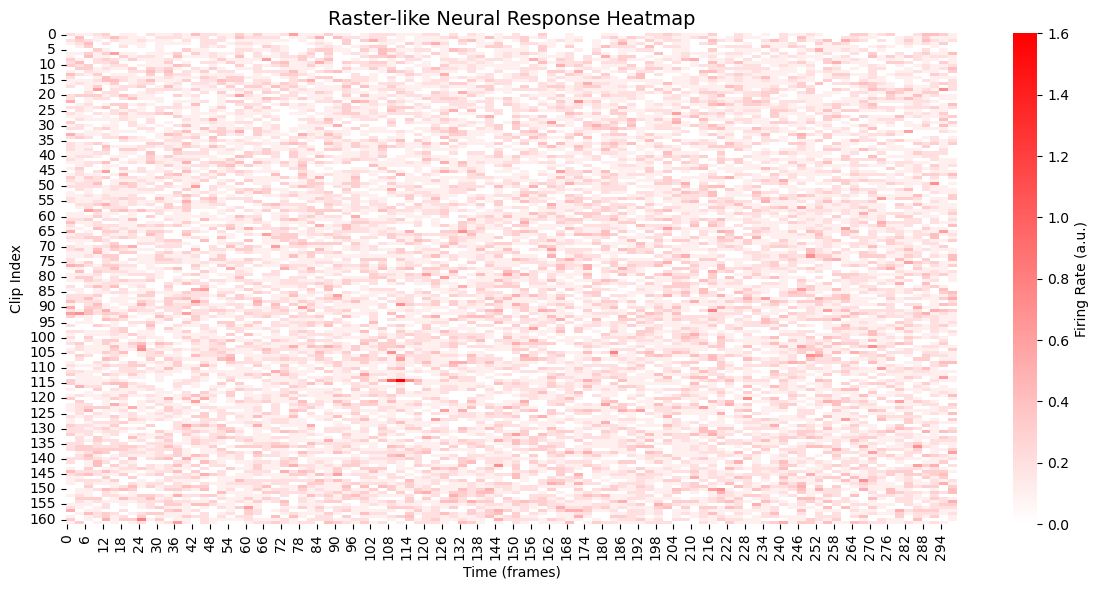

In [24]:
response_matrix = response_sample.mean(dim=1).numpy()  # (N_clips, T)

white_red = LinearSegmentedColormap.from_list("white_red", ["white", "red"])

plt.figure(figsize=(12, 6), facecolor='white')
sns.heatmap(
    response_matrix,
    cmap=white_red,
    cbar_kws={'label': 'Firing Rate (a.u.)'},
    linewidths=0,
    linecolor=None
)

plt.xlabel("Time (frames)")
plt.ylabel("Clip Index")
plt.title("Raster-like Neural Response Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

**Response autocorrelation :**

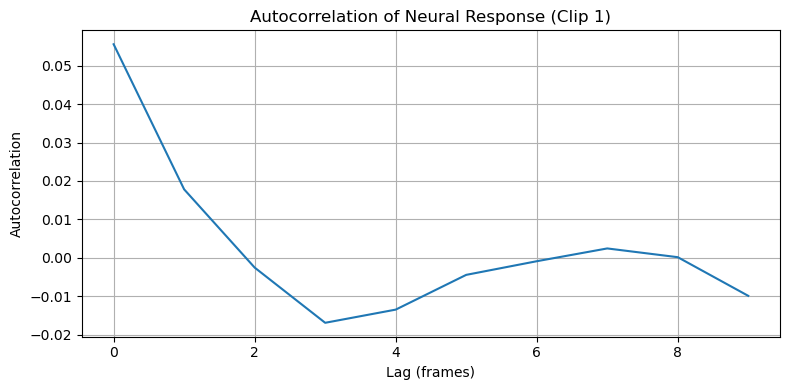

In [25]:
clip_id = 1
neuron_id = 13

signal = response_clips[neuron_id, clip_id].mean(dim=1).numpy()
acf = correlate(signal - signal.mean(), signal - signal.mean(), mode='full')
acf = acf[acf.size // 2:]  # keep positive lags

plt.figure(figsize=(8, 4))
plt.plot(acf)
plt.title(f"Autocorrelation of Neural Response (Clip {clip_id})")
plt.xlabel("Lag (frames)")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.tight_layout()
plt.show()

**Frame brightness and response :**

In [26]:
video_clips.shape

torch.Size([162, 1, 112, 112, 300])

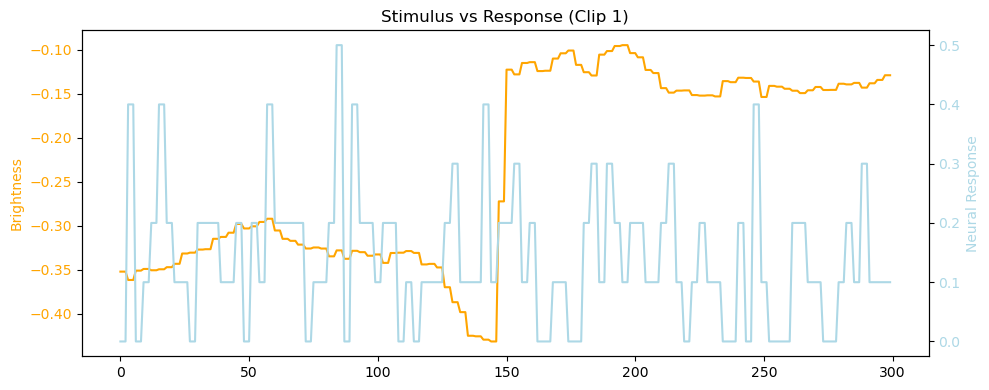

In [27]:
clip_id = 1
neuron_id = 13

video = video_clips[clip_id].squeeze(0).numpy()  # (H, W, T)
frame_mean = video.mean(axis=(0, 1))     # (T,)
response = response_clips[neuron_id, clip_id].mean(dim=0).numpy()

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(frame_mean, label="Frame Brightness", color='orange')
ax1.set_ylabel("Brightness", color='orange')
ax1.tick_params(axis='y', labelcolor='orange')

ax2 = ax1.twinx()
ax2.plot(response, label="Neural Response", color='lightblue')
ax2.set_ylabel("Neural Response", color='lightblue')
ax2.tick_params(axis='y', labelcolor='lightblue')

plt.title(f"Stimulus vs Response (Clip {clip_id})")
plt.xlabel("Time (frames)")
fig.tight_layout()
plt.show()


**Visualizing videos**

We choose one video to visualize :

In [28]:
print(f'We have {dataset.S} videos to choose from.')

studied_video = 1
sample_video, sample_response, sample_signal_power, sample_nrn_mask = dataset[studied_video]

We have 162 videos to choose from.


**Visualizing frames and a GIF from the sample :**

In [29]:
number_of_frames_to_display = 10

# Ensure shape is (C=1, H, W, T), then convert to (H, W, T)
assert sample_video.ndim == 4, "Expected shape (1, H, W, T)"
video_np = sample_video.squeeze().numpy()  # Shape: (H, W, T)

H, W, T = video_np.shape

**Frames :**

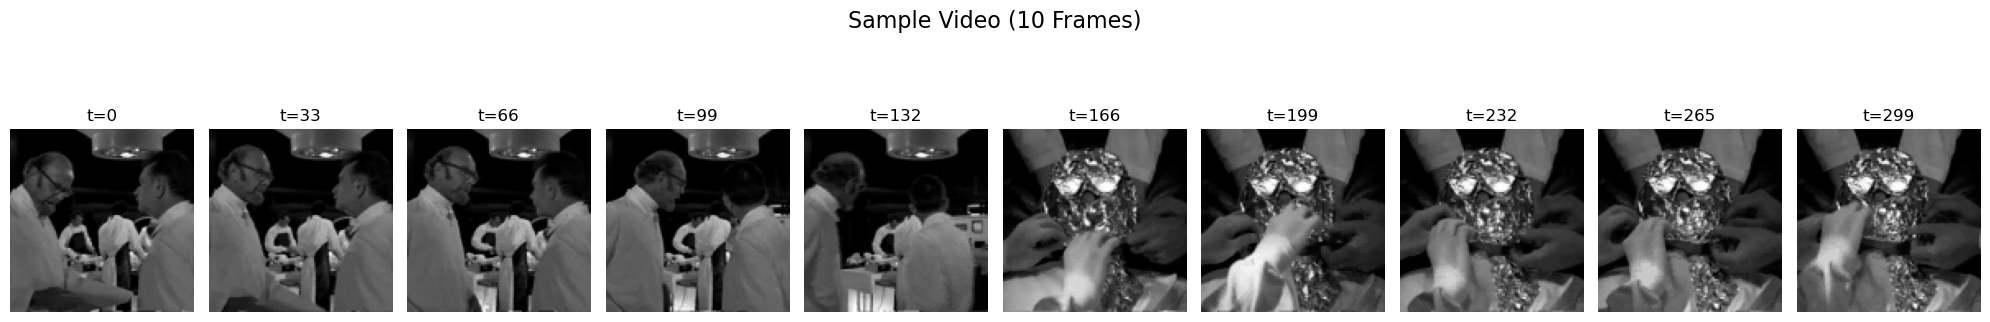

In [30]:
frame_indices = np.linspace(0, T - 1, number_of_frames_to_display, dtype=int)

fig, axes = plt.subplots(1, number_of_frames_to_display, figsize=(20, 4))
for i, t in enumerate(frame_indices):
    ax = axes[i]
    ax.imshow(video_np[:, :, t], cmap='gray')
    ax.set_title(f"t={t}")
    ax.axis('off')
fig.suptitle("Sample Video (10 Frames)", fontsize=16)
plt.tight_layout()
plt.show()

**GIF :**


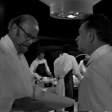

In [31]:
# Normalize video to [0, 1]
video_np = video_np.squeeze()  # (H, W, T)
video_np = (video_np - video_np.min()) / (video_np.max() - video_np.min() + 1e-8)

gif_frames = [(255 * video_np[:, :, t]).astype(np.uint8) for t in range(T)]

gif_bytes = io.BytesIO()
imageio.mimsave(gif_bytes, gif_frames, format='GIF', duration=dataset.dt / 1000)
gif_bytes.seek(0)

gif_base64 = base64.b64encode(gif_bytes.read()).decode('utf-8')

display(HTML(f'<img src="data:image/gif;base64,{gif_base64}" width="258">'))

**Visualizing responses**

In [32]:
print(f'We have {dataset.S} videos to choose from.')

studied_video = 1
sample_video, sample_response, sample_signal_power, sample_nrn_mask = dataset[studied_video]

We have 162 videos to choose from.


Visualize the response for the chosen sample, for a chosen neuron :

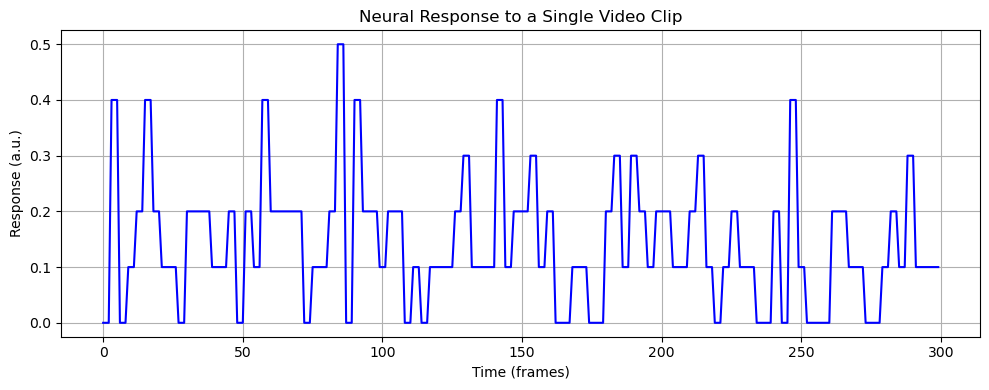

In [38]:
studied_neuron = 13

response = sample_response[studied_neuron, :, :].mean(dim=0).numpy()  # shape: (T,)
t_axis = np.arange(response.shape[0])

plt.figure(figsize=(10, 4))
plt.plot(t_axis, response, color='blue')
plt.xlabel("Time (frames)")
plt.ylabel("Response (a.u.)")
plt.title("Neural Response to a Single Video Clip")
plt.grid(True)
plt.tight_layout()
plt.show()

**Visualizing signal power**

In [41]:
print(f'We have {dataset.S} videoos to choose from.')

studied_video = 125
sample_video, sample_response, sample_signal_power, sample_nrn_mask = dataset[studied_video]

We have 162 videoos to choose from.


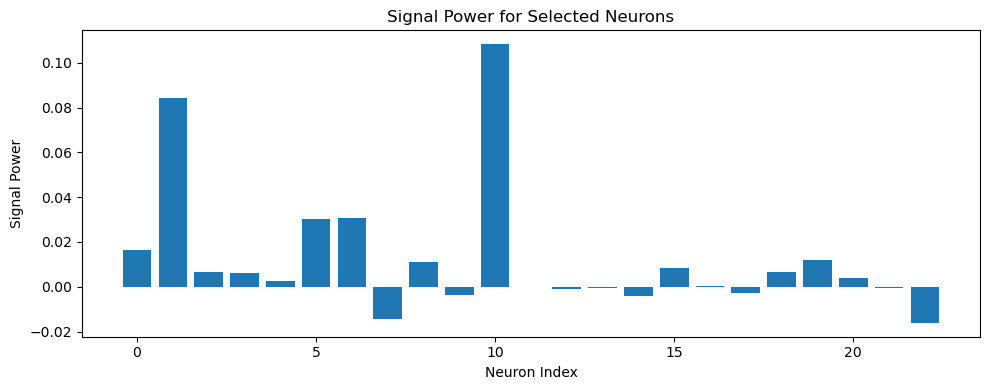

In [42]:
sp_np = sample_signal_power.numpy()
neuron_indices = np.arange(sp_np.shape[0])

sp_values = sp_np[:, 0] if sp_np.ndim > 1 else sp_np
plt.figure(figsize=(10, 4))
plt.bar(neuron_indices, sp_values)
plt.xlabel("Neuron Index")
plt.ylabel("Signal Power")
plt.title("Signal Power for Selected Neurons")
plt.tight_layout()
plt.show()